# Components of the RL Framework

## The 5 Core Components

| Component | Role |
|-----------|------|
| **Environment** | World the agent operates in |
| **Agent** | Learner / decision-maker |
| **State (S)** | Agent's perception of the world |
| **Action (A)** | Set of choices the agent can make |
| **Reward (R)** | Feedback signal guiding learning |

Plus two derived concepts:
- **Policy π** — The agent's strategy
- **Value Function V / Q** — Estimate of how good a state (or action) is

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

print('Libraries loaded')

Libraries loaded


## Component 1: The Environment

The environment defines:
- The **state space** S — all possible situations
- The **action space** A — all possible actions
- The **transition dynamics** P(s'|s, a) — how actions change states
- The **reward function** R(s, a) — what reward results from each (state, action)

We'll use a **Grid World** — a classic RL teaching environment.

/tmp/ipykernel_10020/2741256356.py:93: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10020/2741256356.py:93: UserWarning: Glyph 128679 (\N{CONSTRUCTION SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10020/2741256356.py:93: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129302 (\N{ROBOT FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128679 (\N{CONSTRUCTION SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


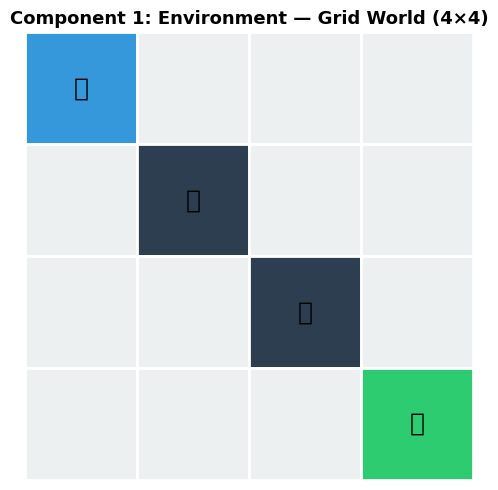

State Space: 16 states (each cell = one state)
Action Space: 4 actions ['↑ UP', '↓ DOWN', '← LEFT', '→ RIGHT']


In [3]:
# ============================================================
# CELL 2: Grid World Environment
# ============================================================
# 4x4 grid, agent starts at (0,0), goal at (3,3)
# Obstacle at (1,1) and (2,2)
# Actions: UP, DOWN, LEFT, RIGHT

class GridWorldEnv:
    """4x4 Grid World with obstacles."""

    UP, DOWN, LEFT, RIGHT = 0, 1, 2, 3
    ACTION_NAMES = {0:'↑ UP', 1:'↓ DOWN', 2:'← LEFT', 3:'→ RIGHT'}

    def __init__(self, size=4):
        self.size = size
        self.start = (0, 0)
        self.goal  = (size-1, size-1)
        self.obstacles = {(1, 1), (2, 2)}
        self.agent_pos = None

    @property
    def n_states(self):
        return self.size * self.size

    @property
    def n_actions(self):
        return 4

    def pos_to_state(self, row, col):
        return row * self.size + col

    def state_to_pos(self, state):
        return state // self.size, state % self.size

    def reset(self):
        self.agent_pos = self.start
        return self.pos_to_state(*self.agent_pos)

    def step(self, action):
        row, col = self.agent_pos

        if   action == self.UP:    new_pos = (row-1, col)
        elif action == self.DOWN:  new_pos = (row+1, col)
        elif action == self.LEFT:  new_pos = (row, col-1)
        elif action == self.RIGHT: new_pos = (row, col+1)

        # Boundary check
        nr, nc = new_pos
        if 0 <= nr < self.size and 0 <= nc < self.size:
            if new_pos not in self.obstacles:
                self.agent_pos = new_pos

        # Rewards
        if self.agent_pos == self.goal:
            return self.pos_to_state(*self.agent_pos), +10, True
        else:
            return self.pos_to_state(*self.agent_pos), -1, False

    def render(self, title='Grid World'):
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))
        ax.set_xlim(0, self.size)
        ax.set_ylim(0, self.size)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.axis('off')

        for r in range(self.size):
            for c in range(self.size):
                pos = (r, c)
                x, y = c, self.size - r - 1  # flip row for display

                if pos in self.obstacles:
                    color = '#2c3e50'
                    text = '🚧'
                elif pos == self.goal:
                    color = '#2ecc71'
                    text = '🎯'
                elif pos == self.agent_pos:
                    color = '#3498db'
                    text = '🤖'
                elif pos == self.start:
                    color = '#ecf0f1'
                    text = 'S'
                else:
                    color = '#ecf0f1'
                    text = ''

                rect = patches.Rectangle((x, y), 1, 1, linewidth=2,
                                          edgecolor='white', facecolor=color)
                ax.add_patch(rect)
                ax.text(x + 0.5, y + 0.5, text, ha='center', va='center', fontsize=18)

        plt.tight_layout()
        plt.show()


env = GridWorldEnv(size=4)
env.reset()
env.render('Component 1: Environment — Grid World (4×4)')
print(f'State Space: {env.n_states} states (each cell = one state)')
print(f'Action Space: {env.n_actions} actions {list(GridWorldEnv.ACTION_NAMES.values())}')

## Component 2: Policy (π)

The **policy** defines the agent's behaviour — which action to take in each state.

- **Deterministic policy**: π(s) → a (one specific action per state)
- **Stochastic policy**: π(a|s) → probability distribution over actions

### Exploration vs Exploitation: ε-greedy Policy
The most common strategy:
- With probability **ε** → explore (random action)
- With probability **1-ε** → exploit (best known action)

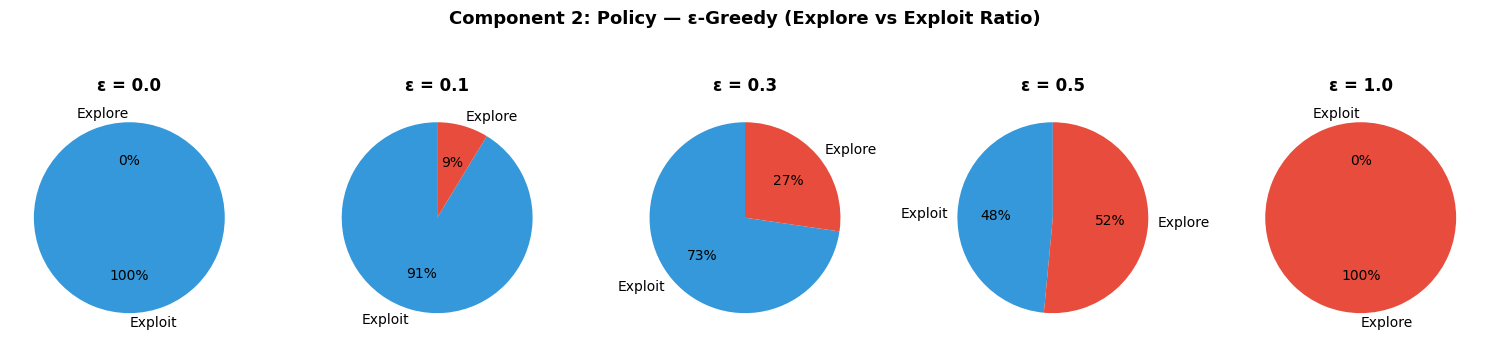

ε=0.0 → Pure exploitation (greedy)  |  ε=1.0 → Pure exploration (random)
Typical training: start ε=1.0, decay to ε=0.01 over time


In [4]:
# ============================================================
# CELL 3: Policy — Epsilon-Greedy
# ============================================================

class EpsilonGreedyPolicy:
    """ε-greedy policy for exploration vs exploitation."""

    def __init__(self, n_states, n_actions, epsilon=0.3):
        self.n_actions = n_actions
        self.epsilon   = epsilon
        # Q-table: estimated value of each (state, action) pair
        self.Q = np.zeros((n_states, n_actions))

    def select_action(self, state):
        if np.random.random() < self.epsilon:
            # EXPLORE: random action
            return np.random.randint(self.n_actions), 'explore'
        else:
            # EXPLOIT: best known action
            return np.argmax(self.Q[state]), 'exploit'

    def update_Q(self, state, action, reward, next_state, alpha=0.1, gamma=0.9):
        """Q-learning update rule."""
        target = reward + gamma * np.max(self.Q[next_state])
        self.Q[state, action] += alpha * (target - self.Q[state, action])


# Visualise epsilon-greedy decision behaviour
epsilons = [0.0, 0.1, 0.3, 0.5, 1.0]
n_trials  = 1000

fig, axes = plt.subplots(1, len(epsilons), figsize=(15, 4))
fig.suptitle('Component 2: Policy — ε-Greedy (Explore vs Exploit Ratio)',
             fontsize=13, fontweight='bold')

for ax, eps in zip(axes, epsilons):
    choices = ['Exploit' if np.random.random() > eps else 'Explore'
               for _ in range(n_trials)]
    counts = {'Exploit': choices.count('Exploit'), 'Explore': choices.count('Explore')}

    ax.pie(counts.values(), labels=counts.keys(),
           colors=['#3498db', '#e74c3c'],
           autopct='%1.0f%%', startangle=90,
           textprops={'fontsize': 10})
    ax.set_title(f'ε = {eps}', fontweight='bold')

plt.tight_layout()
plt.show()
print('ε=0.0 → Pure exploitation (greedy)  |  ε=1.0 → Pure exploration (random)')
print('Typical training: start ε=1.0, decay to ε=0.01 over time')

## Component 3: Value Function

The **value function** estimates long-term expected return from a state.

- **V(s)** — State-value: How good is it to be in state *s*?
- **Q(s,a)** — Action-value: How good is it to take action *a* in state *s*?

The **Q-table** is a lookup table storing Q(s,a) for all state-action pairs.

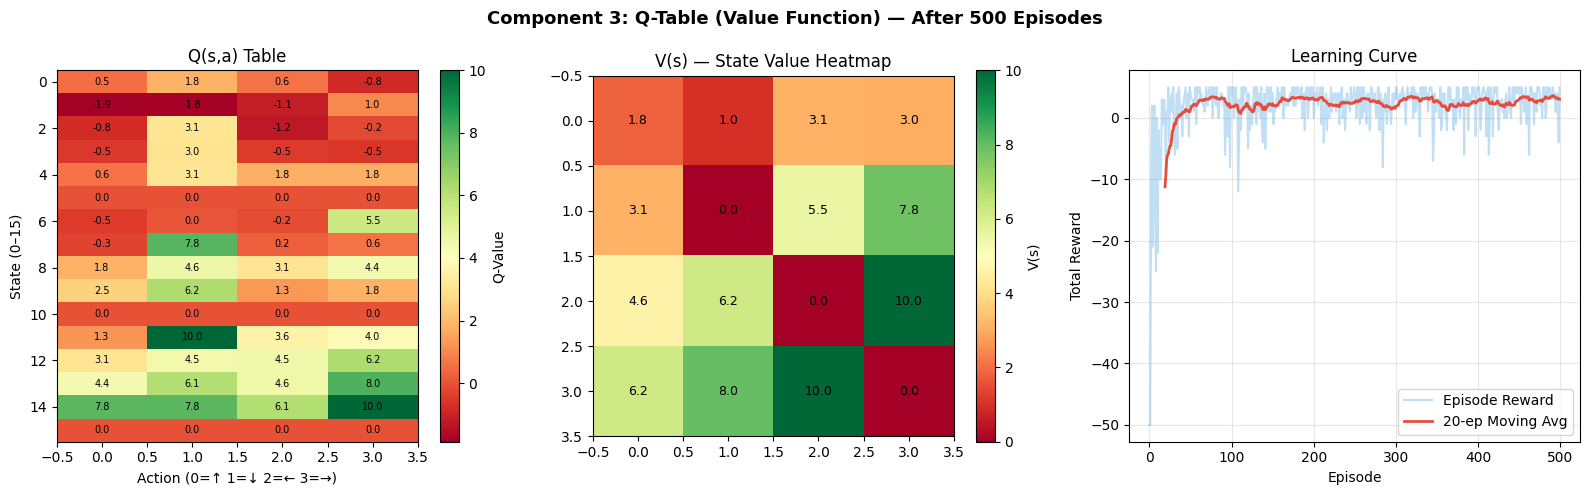


Greener cells = higher value. The agent learns that states closer to
   the goal are more valuable!


In [5]:
# ============================================================
# CELL 4: Q-Table Learning — Training Loop
# ============================================================

np.random.seed(42)
env    = GridWorldEnv(size=4)
policy = EpsilonGreedyPolicy(env.n_states, env.n_actions, epsilon=0.3)

n_episodes = 500
rewards_history = []

for episode in range(n_episodes):
    state = env.reset()
    total_reward = 0

    for step in range(50):
        action, mode = policy.select_action(state)
        next_state, reward, done = env.step(action)

        # Update Q-table (learning!)
        policy.update_Q(state, action, reward, next_state)

        total_reward += reward
        state = next_state

        if done:
            break

    rewards_history.append(total_reward)

# Plot Q-table as heatmap and learning curve
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Component 3: Q-Table (Value Function) — After 500 Episodes',
             fontsize=13, fontweight='bold')

# Left: Q-table heatmap
im = axes[0].imshow(policy.Q, cmap='RdYlGn', aspect='auto')
axes[0].set_xlabel('Action (0=↑ 1=↓ 2=← 3=→)')
axes[0].set_ylabel('State (0–15)')
axes[0].set_title('Q(s,a) Table')
plt.colorbar(im, ax=axes[0], label='Q-Value')

# Add state labels
for i in range(env.n_states):
    for j in range(env.n_actions):
        axes[0].text(j, i, f'{policy.Q[i,j]:.1f}',
                     ha='center', va='center', fontsize=7,
                     color='black')

# Middle: V(s) — best Q per state reshaped as grid
V = np.max(policy.Q, axis=1).reshape(4, 4)
im2 = axes[1].imshow(V, cmap='RdYlGn')
axes[1].set_title('V(s) — State Value Heatmap')
plt.colorbar(im2, ax=axes[1], label='V(s)')
for r in range(4):
    for c in range(4):
        axes[1].text(c, r, f'{V[r,c]:.1f}', ha='center', va='center',
                     fontsize=9, color='black')

# Right: Learning curve
window = 20
moving_avg = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
axes[2].plot(rewards_history, alpha=0.3, color='#3498db', label='Episode Reward')
axes[2].plot(range(window-1, len(rewards_history)), moving_avg,
             color='#e74c3c', linewidth=2, label=f'{window}-ep Moving Avg')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Total Reward')
axes[2].set_title('Learning Curve')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('\nGreener cells = higher value. The agent learns that states closer to')
print('   the goal are more valuable!')

## Component 4: Reward Function

The reward function defines **what the agent should optimise**. It is the most important design decision.

**Reward Shaping** examples for the same grid world:
- **Sparse**: only +10 at goal → hard to learn
- **Dense**: -1 per step + +10 at goal → easier to learn  
- **Distance-based**: reward proportional to closeness to goal

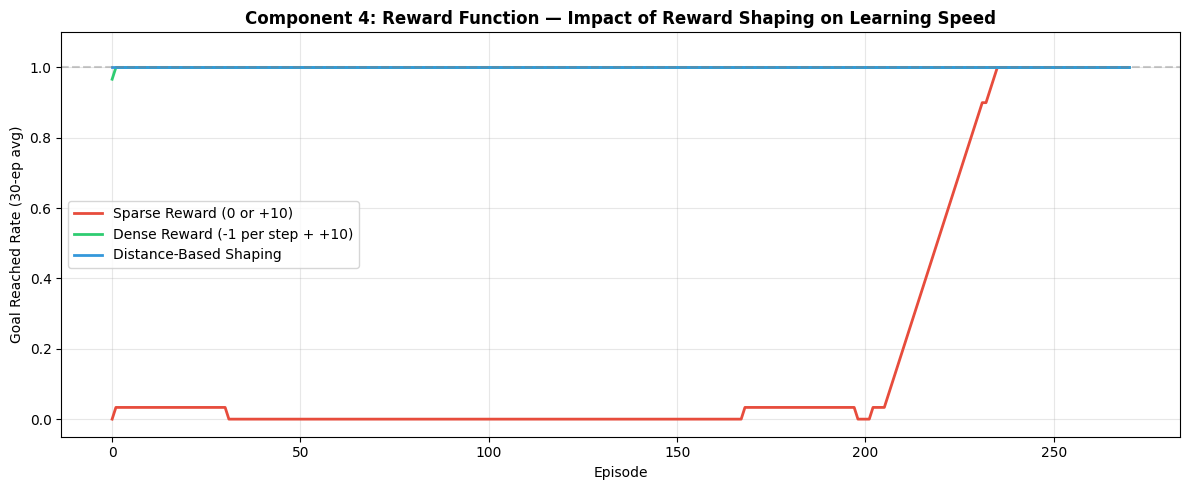


 Well-designed reward functions drastically accelerate learning!
   Sparse rewards make learning very difficult — agent rarely gets any signal.


In [6]:
# ============================================================
# CELL 5: Compare Reward Shaping Strategies
# ============================================================

class GridWorldSparse(GridWorldEnv):
    """Only reward at goal."""
    def step(self, action):
        state, reward, done = super().step(action)
        reward = +10 if done else 0
        return state, reward, done

class GridWorldDense(GridWorldEnv):
    """Step penalty + goal reward."""
    def step(self, action):
        state, reward, done = super().step(action)
        return state, reward, done  # default: -1 + +10

class GridWorldDistBased(GridWorldEnv):
    """Manhattan distance-based shaping."""
    def step(self, action):
        state, _, done = super().step(action)
        r, c = self.agent_pos
        gr, gc = self.goal
        dist = abs(r - gr) + abs(c - gc)
        reward = +10 - dist if done else -dist * 0.5
        return state, reward, done


def train(env_class, n_episodes=300, epsilon=0.4, label=''):
    np.random.seed(42)
    env    = env_class()
    policy = EpsilonGreedyPolicy(env.n_states, env.n_actions, epsilon)
    goal_reached = []

    for ep in range(n_episodes):
        state = env.reset()
        reached = False
        for _ in range(50):
            action, _ = policy.select_action(state)
            next_state, reward, done = env.step(action)
            policy.update_Q(state, action, reward, next_state)
            state = next_state
            if done:
                reached = True
                break
        goal_reached.append(1 if reached else 0)

    return goal_reached


sparse_goals   = train(GridWorldSparse,   label='Sparse')
dense_goals    = train(GridWorldDense,    label='Dense')
dist_goals     = train(GridWorldDistBased, label='Distance-Based')

def smooth(x, w=30):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(sparse_goals),  color='#e74c3c', lw=2, label='Sparse Reward (0 or +10)')
ax.plot(smooth(dense_goals),   color='#2ecc71', lw=2, label='Dense Reward (-1 per step + +10)')
ax.plot(smooth(dist_goals),    color='#3498db', lw=2, label='Distance-Based Shaping')
ax.set_xlabel('Episode')
ax.set_ylabel('Goal Reached Rate (30-ep avg)')
ax.set_title('Component 4: Reward Function — Impact of Reward Shaping on Learning Speed',
             fontweight='bold')
ax.set_ylim(-0.05, 1.1)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n Well-designed reward functions drastically accelerate learning!')
print('   Sparse rewards make learning very difficult — agent rarely gets any signal.')

## Component 5: The Model (Optional)

Some RL approaches include a **model** of the environment (transition and reward dynamics).

| Type | Uses a Model? | Examples |
|------|--------------|----------|
| **Model-Free** | ❌ No | Q-Learning, SARSA, PPO |
| **Model-Based** | ✅ Yes | Dyna-Q, World Models, AlphaZero |

Model-free is simpler and more widely used; model-based is more sample-efficient.

---
### Summary of RL Components

```
RL Framework
├── Environment  → defines states, actions, transitions, rewards
├── Agent        → observes, decides, learns
├── Policy (π)   → how the agent selects actions  
├── Value Fn (V/Q) → estimates expected long-term reward
├── Reward (R)   → the optimisation signal
└── Model (optional) → internal representation of dynamics
```